# **K-Nearest Neighbour**
# **Dataset: Salary Cencus**


## Step-01 Load Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.metrics import accuracy_score

import warnings
warnings.filterwarnings("ignore")

## Step-02 Load Dataset

In [4]:
df = pd.read_csv('salary_census.csv')
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


## Step-03 Data Preprocessing

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [6]:
df.shape

(32561, 15)

In [7]:
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64

In [8]:
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education.num',
       'marital.status', 'occupation', 'relationship', 'race', 'sex',
       'capital.gain', 'capital.loss', 'hours.per.week', 'native.country',
       'income'],
      dtype='object')

In [9]:
df['income'].value_counts()

income
<=50K    24720
>50K      7841
Name: count, dtype: int64

In [10]:
df['workclass'].value_counts()

workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
?                    1836
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64

In [11]:
df['occupation'].value_counts()

occupation
Prof-specialty       4140
Craft-repair         4099
Exec-managerial      4066
Adm-clerical         3770
Sales                3650
Other-service        3295
Machine-op-inspct    2002
?                    1843
Transport-moving     1597
Handlers-cleaners    1370
Farming-fishing       994
Tech-support          928
Protective-serv       649
Priv-house-serv       149
Armed-Forces            9
Name: count, dtype: int64

In [36]:
df['capital.gain'].value_counts().unique()

array([29849,   347,   284,   246,   159,    97,    70,    69,    55,
          53,    48,    43,    42,    41,    37,    34,    32,    31,
          27,    26,    25,    24,    23,    22,    20,    19,    17,
          16,    15,    14,    12,    11,     9,     8,     7,     6,
           5,     4,     3,     2,     1], dtype=int64)

In [37]:
df['capital.loss'].value_counts().unique()

array([31042,   202,   168,   159,    51,    49,    47,    42,    40,
          39,    34,    25,    24,    23,    22,    21,    20,    18,
          17,    15,    14,    12,    10,     9,     8,     7,     6,
           5,     4,     3,     2,     1], dtype=int64)

In [12]:
df_cleaned = df.replace('?',pd.NA).dropna()
df_cleaned.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
5,34,Private,216864,HS-grad,9,Divorced,Other-service,Unmarried,White,Female,0,3770,45,United-States,<=50K
6,38,Private,150601,10th,6,Separated,Adm-clerical,Unmarried,White,Male,0,3770,40,United-States,<=50K


In [13]:
df['native.country'].value_counts()

native.country
United-States                 29170
Mexico                          643
?                               583
Philippines                     198
Germany                         137
Canada                          121
Puerto-Rico                     114
El-Salvador                     106
India                           100
Cuba                             95
England                          90
Jamaica                          81
South                            80
China                            75
Italy                            73
Dominican-Republic               70
Vietnam                          67
Guatemala                        64
Japan                            62
Poland                           60
Columbia                         59
Taiwan                           51
Haiti                            44
Iran                             43
Portugal                         37
Nicaragua                        34
Peru                             31
Greece       

In [14]:
df_cleaned['workclass'].value_counts()

workclass
Private             22286
Self-emp-not-inc     2499
Local-gov            2067
State-gov            1279
Self-emp-inc         1074
Federal-gov           943
Without-pay            14
Name: count, dtype: int64

In [15]:
df_cleaned.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education.num',
       'marital.status', 'occupation', 'relationship', 'race', 'sex',
       'capital.gain', 'capital.loss', 'hours.per.week', 'native.country',
       'income'],
      dtype='object')

In [16]:
df_cleaned.drop(['fnlwgt','education','relationship','native.country','occupation'], axis=1, inplace=True)


In [17]:
df_cleaned.drop(['marital.status'], axis=1, inplace=True)

* **Let's take first 10000 rows in the column**

In [18]:
# Select first 10000 rows in the dataset
df1 = df_cleaned.head(10000)

## Step-04 Feature Encoding

* **Let's do label Encoding on Target/label**

In [19]:
le = LabelEncoder()

In [20]:
df1.head()

,age,workclass,education.num,race,sex,capital.gain,capital.loss,hours.per.week,income
1,82,Private,9,White,Female,0,4356,18,<=50K
3,54,Private,4,White,Female,0,3900,40,<=50K
4,41,Private,10,White,Female,0,3900,40,<=50K
5,34,Private,9,White,Female,0,3770,45,<=50K
6,38,Private,6,White,Male,0,3770,40,<=50K


In [21]:
df1['income'] = le.fit_transform(df1['income'])

* **Let's do One Hot Encoding**

In [22]:
df_cleaned.columns

Index(['age', 'workclass', 'education.num', 'race', 'sex', 'capital.gain',
       'capital.loss', 'hours.per.week', 'income'],
      dtype='object')

In [23]:
df1.head()

,age,workclass,education.num,race,sex,capital.gain,capital.loss,hours.per.week,income
1,82,Private,9,White,Female,0,4356,18,0
3,54,Private,4,White,Female,0,3900,40,0
4,41,Private,10,White,Female,0,3900,40,0
5,34,Private,9,White,Female,0,3770,45,0
6,38,Private,6,White,Male,0,3770,40,0


In [24]:
df_ohe = pd.get_dummies(df1,columns=['workclass', 'race','sex'])

In [25]:
df_ohe.head()

,age,education.num,capital.gain,capital.loss,hours.per.week,income,workclass_Federal-gov,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay,race_Amer-Indian-Eskimo,race_Asian-Pac-Islander,race_Black,race_Other,race_White,sex_Female,sex_Male
1,82,9,0,4356,18,0,False,False,True,False,False,False,False,False,False,False,False,True,True,False
3,54,4,0,3900,40,0,False,False,True,False,False,False,False,False,False,False,False,True,True,False
4,41,10,0,3900,40,0,False,False,True,False,False,False,False,False,False,False,False,True,True,False
5,34,9,0,3770,45,0,False,False,True,False,False,False,False,False,False,False,False,True,True,False
6,38,6,0,3770,40,0,False,False,True,False,False,False,False,False,False,False,False,True,False,True


In [26]:
df_ohe.shape

(10000, 20)

## Step-05 Split the data in Training and Testing sets

In [27]:
X = df_ohe.drop(['income'], axis = 1)
y = df_ohe['income']

In [28]:
X_train,X_test , y_train , y_test = train_test_split(X,y,test_size=0.2 , random_state=42)
len(X_train), len(X_test) , len(y_train) , len(y_test)

(8000, 2000, 8000, 2000)

In [29]:
# Function to choose the optimal value of k for KNN
def choose_k(X_train, y_train, X_test, y_test, max_k=10):
    # Generate a list of k values from 1 to max_k
    k_values = list(range(1, max_k + 1))
    accuracy_values = []  # List to store accuracy for each k
    
    # Iterate over each k value to evaluate its performance
    for k in k_values:
        # Create a KNN classifier with the current k value
        knn = KNeighborsClassifier(n_neighbors=k) 
        # Fit the model on the training data
        knn.fit(X_train, y_train) 
        # Predict the labels for the test data
        y_pred = knn.predict(X_test)
        # Calculate the accuracy of the predictions
        accuracy = accuracy_score(y_test, y_pred)
        # Append the accuracy to the list
        accuracy_values.append(accuracy)
    
    # Visualize the accuracy for different k values
    plt.figure(figsize=(10, 6))
    plt.plot(k_values, accuracy_values, marker='o', linestyle='-')
    plt.title('Accuracy vs. Number of Neighbors (k)')
    plt.xlabel('Number of Neighbors (k)')
    plt.ylabel('Accuracy')
    plt.xticks(k_values)
    plt.grid(True)
    plt.show()

    # Find the best k value based on the highest accuracy
    best_k = k_values[accuracy_values.index(max(accuracy_values))]
    return best_k

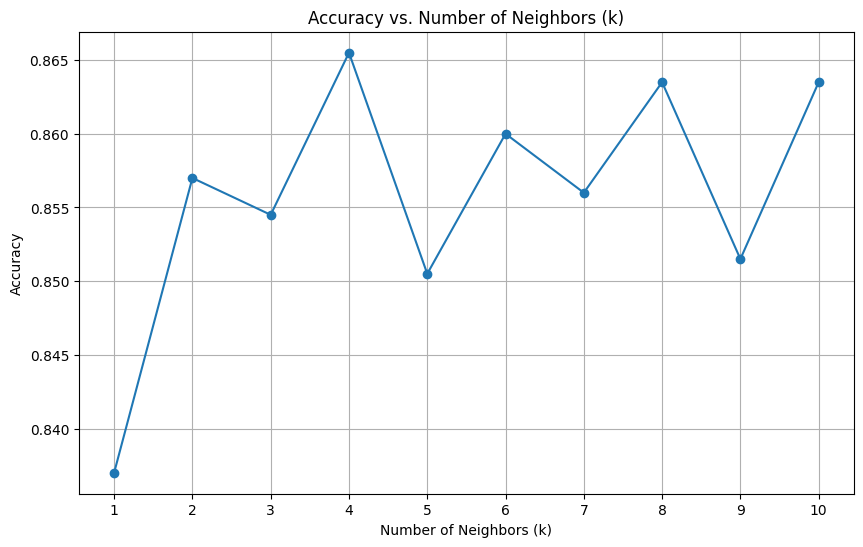

Best k: 4


In [30]:
# Choose the best k value
best_k = choose_k(X_train, y_train, X_test, y_test)
print("Best k:", best_k)

**Insights:**

- Plot shows best optimal value of k is 4
- Accuracy = 86.5%

## Step-06 Model Selection

In [31]:
# Create and train KNN model with best k
model = KNeighborsClassifier(n_neighbors=best_k)

#model_2 = SVC(kernel='linear', C=1)

## Step-07 Make Predictions

In [32]:
model.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=4)

In [33]:
#model_2.fit(X_train,y_train)

In [34]:
y_pred = model.predict(X_test)

## Step-08 Evaluation Matrix

In [35]:
Accuracy = accuracy_score(y_test,y_pred)
print(f"Accuracy: {Accuracy:.3f}")

Accuracy: 0.866
